# Task: Cancer Diagnosis using NN

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Read data

In [4]:
data = pd.read_csv('./Cancer_data.csv')

In [6]:
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [8]:
data.shape

(569, 32)

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [12]:
data['diagnosis'].unique()

array(['M', 'B'], dtype=object)

In [14]:
# Get the x and y data
x = data.iloc[:, 2:]
y = pd.DataFrame(data['diagnosis'])

## One hot encoder

In [17]:
from sklearn.preprocessing import LabelEncoder

### encode the target

In [19]:
label_encoder = LabelEncoder()
y_encode = label_encoder.fit_transform(y.values.ravel())

## Feature Scaling

In [23]:
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler(feature_range = (0, 1))

In [25]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

In [27]:
x_scaled = sc.fit_transform(x)

## Splitting the dataset into the Training set and Test set

In [30]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y_encode, test_size = 0.2,\
                                                    random_state = 0)

## size/shape of dataframe

In [33]:
n_samples = x_train.shape[0]
n_features = x_train.shape[1]

## Make the NN using sequential API

In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(Dense(512, activation='tanh', input_shape=(n_features,)))
model.add(Dense(256, activation='sigmoid'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='SGD', loss='binary_crossentropy', metrics=['accuracy'])


C:\Users\wayne\anaconda3\envs\deeplearning-env\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Make the NN using functional API

In [38]:
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

n_features = 30  # 
input_layer = Input(shape=(n_features,))
hidden_layer_1 = Dense(units=512, kernel_initializer='uniform', activation='tanh')(input_layer)
hidden_layer_2 = Dense(units=256, kernel_initializer='uniform', activation='sigmoid')(hidden_layer_1)
output_layer = Dense(units=1, kernel_initializer='uniform', activation='sigmoid')(hidden_layer_2)
my_classifier = Model(inputs=input_layer, outputs=output_layer)
# Compiling the ANN
my_classifier.compile(optimizer='SGD', loss='binary_crossentropy', metrics=['accuracy'])


## plot the model

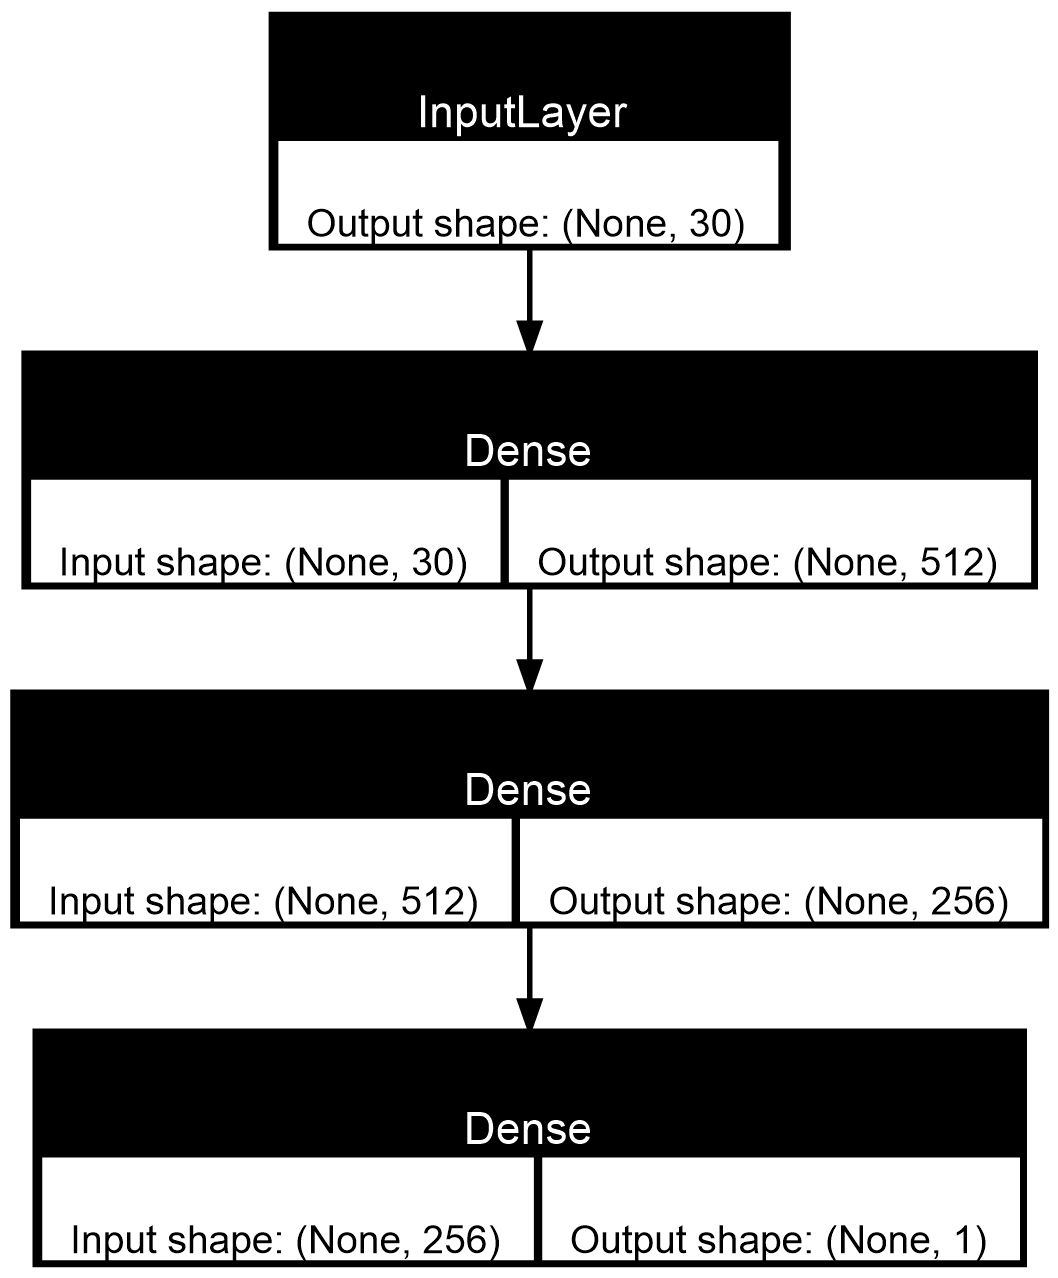

In [42]:
from tensorflow.keras.utils import plot_model
plot_model(my_classifier, to_file='model.png', show_shapes=True)

In [43]:
my_classifier.summary()




Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │        15,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 147,457 (576.00 KB)

 Trainable params: 147,457 (576.00 KB)

 Non-trainable params: 0 (0.00 B)

## Fitting the ANN to the Training set

In [45]:
history = my_classifier.fit(x_train, y_train, validation_split=0.2,
                            batch_size = 10, epochs = 100)

Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6659 - loss: 0.6452 - val_accuracy: 0.6044 - val_loss: 0.6729
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6620 - loss: 0.6315 - val_accuracy: 0.6044 - val_loss: 0.6518
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6598 - loss: 0.6198 - val_accuracy: 0.6154 - val_loss: 0.6363
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6465 - loss: 0.6200 - val_accuracy: 0.6044 - val_loss: 0.6369
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6277 - loss: 0.6162 - val_accuracy: 0.6154 - val_loss: 0.6058
Epoch 6/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6525 - loss: 0.5843 - val_accuracy: 0.6044 - val_loss: 0.5988
Epoch 7/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6696 - loss: 0.5639 - val_accuracy: 0.7143 - val_loss: 0.5612
Epoch 8/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7169 - loss: 0.5418 - val_accuracy: 0.6813 - 

In [90]:
# 改用更先進的 Optimizer（優化器）
from tensorflow.keras.optimizers import Adam

my_classifier.compile(optimizer=Adam(learning_rate=0.001),
                      loss='binary_crossentropy',
                      metrics=['accuracy'])
history = my_classifier.fit(x_train, y_train, validation_split=0.2,
                            batch_size = 10, epochs = 100)

Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9894 - loss: 0.0338 - val_accuracy: 1.0000 - val_loss: 0.0057
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9879 - loss: 0.0488 - val_accuracy: 1.0000 - val_loss: 0.0039
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9942 - loss: 0.0151 - val_accuracy: 1.0000 - val_loss: 0.0015
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9952 - loss: 0.0179 - val_accuracy: 1.0000 - val_loss: 0.0045
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9773 - loss: 0.0408 - val_accuracy: 1.0000 - val_loss: 0.0031
Epoch 6/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0055 - val_accuracy: 1.0000 - val_loss: 0.0028
Epoch 7/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9943 - loss: 0.0228 - val_accuracy: 1.0000 - val_loss: 0.0022
Epoch 8/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9886 - loss: 0.0368 - val_accuracy: 1.0000 - v

In [88]:
#加上 EarlyStopping（避免 overfitting）
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = my_classifier.fit(x_train, y_train,
                            validation_data=(x_test, y_test),
                            epochs=100,
                            batch_size=32,
                            callbacks=[early_stop])


Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9974 - loss: 0.0193 - val_accuracy: 0.9912 - val_loss: 0.0518
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9993 - loss: 0.0081 - val_accuracy: 0.9912 - val_loss: 0.0520
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9951 - loss: 0.0087 - val_accuracy: 0.9912 - val_loss: 0.0522
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0063 - val_accuracy: 0.9912 - val_loss: 0.0524
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9965 - loss: 0.0109 - val_accuracy: 0.9912 - val_loss: 0.0524
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0062 - val_accuracy: 0.9912 - val_loss: 0.0524
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9973 - loss: 0.0061 - val_accuracy: 0.9912 - val_loss: 0.0524
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0033 - val_accuracy: 0.9912 - v

In [85]:
#Learning Rate Scheduler（動態調整學習率）
from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)

history = my_classifier.fit(x_train, y_train,
                            validation_data=(x_test, y_test),
                            epochs=100,
                            batch_size=32,
                            callbacks=[lr_scheduler])


Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9860 - loss: 0.0289 - val_accuracy: 0.9912 - val_loss: 0.0450 - learning_rate: 0.0010
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9926 - loss: 0.0210 - val_accuracy: 0.9912 - val_loss: 0.0464 - learning_rate: 0.0010
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9989 - loss: 0.0063 - val_accuracy: 0.9912 - val_loss: 0.0466 - learning_rate: 0.0010
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9967 - loss: 0.0141 - val_accuracy: 0.9912 - val_loss: 0.0475 - learning_rate: 0.0010
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9973 - loss: 0.0093 - val_accuracy: 0.9912 - val_loss: 0.0468 - learning_rate: 0.0010
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9906 - loss: 0.0142 
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9908 - loss: 0.0140 - val_acc

In [110]:
# 加上 Dropout 或 Batch Normalization 防止過擬合
from tensorflow.keras.layers import Dropout, BatchNormalization

input_layer = Input(shape=(n_features,))
x = Dense(512, activation='tanh')(input_layer)
x = Dropout(0.3)(x)
x = Dense(256, activation='sigmoid')(x)
x = BatchNormalization()(x)
output_layer = Dense(1, activation='sigmoid')(x)

my_classifier = Model(inputs=input_layer, outputs=output_layer)
my_classifier.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [112]:
history = my_classifier.fit(x_train, y_train,
                            validation_data=(x_test, y_test),
                            epochs=100,
                            batch_size=32,
                            class_weight=class_weight_dict,
                            callbacks=[early_stop])

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8685 - loss: 0.2547 - val_accuracy: 0.9386 - val_loss: 0.2305
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9571 - loss: 0.1435 - val_accuracy: 0.9298 - val_loss: 0.2080
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9144 - loss: 0.1936 - val_accuracy: 0.9298 - val_loss: 0.1892
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9650 - loss: 0.1078 - val_accuracy: 0.9298 - val_loss: 0.1855
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9645 - loss: 0.0802 - val_accuracy: 0.9474 - val_loss: 0.1945
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9618 - loss: 0.1166 - val_accuracy: 0.9561 - val_loss: 0.1757
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9647 - loss: 0.0731 - val_accuracy: 0.9474 - val_loss: 0.1759
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9432 - loss: 0.1289 - val_accuracy: 0.9561 - 

## Make predictions
### Predicting the Train set results

In [115]:
# Make predictions
# Predicting the Test set results
y_pred_train = my_classifier.predict(x_train)
y_pred_train = (y_pred_train > 0.5)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


### Predicting the Test set results

In [118]:
# Predicting the Test set results
y_pred_test = my_classifier.predict(x_test)
y_pred_test = (y_pred_test > 0.5)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


### Making the Confusion Matrix

In [121]:
# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_test)

In [123]:
print(cm)


[[61  6]
 [ 1 46]]


In [131]:
#訓練集中惡性（1）與良性（0）樣本比例失衡
from sklearn.utils import class_weight
import numpy as np

class_weights = class_weight.compute_class_weight(class_weight='balanced',
                                                  classes=np.unique(y_train),
                                                  y=y_train)
class_weight_dict = dict(enumerate(class_weights))

history = model.fit(x_train, y_train,
          validation_data=(x_test, y_test),
          epochs=100,
          class_weight=class_weight_dict)


Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9811 - loss: 0.0651 - val_accuracy: 0.9561 - val_loss: 0.0784
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9775 - loss: 0.0614 - val_accuracy: 0.9561 - val_loss: 0.0786
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9752 - loss: 0.0676 - val_accuracy: 0.9561 - val_loss: 0.0810
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9717 - loss: 0.0818 - val_accuracy: 0.9649 - val_loss: 0.0826
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9819 - loss: 0.0554 - val_accuracy: 0.9561 - val_loss: 0.0815
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9786 - loss: 0.0562 - val_accuracy: 0.9561 - val_loss: 0.0802
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9567 - loss: 0.0937 - val_accuracy: 0.9561 - val_loss: 0.0801
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9773 - loss: 0.0675 - val_accuracy: 0.9561 - v

In [132]:
y_pred_train = model.predict(x_train)
y_pred_train = (y_pred_train > 0.5)
y_pred_test = model.predict(x_test)
y_pred_test = (y_pred_test > 0.5)
cm = confusion_matrix(y_test, y_pred_test)
print (cm)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
[[64  3]
 [ 2 45]]


### list all the data in history

In [136]:
# list all the data in history
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


### Plot the accuracy for both train and validation set

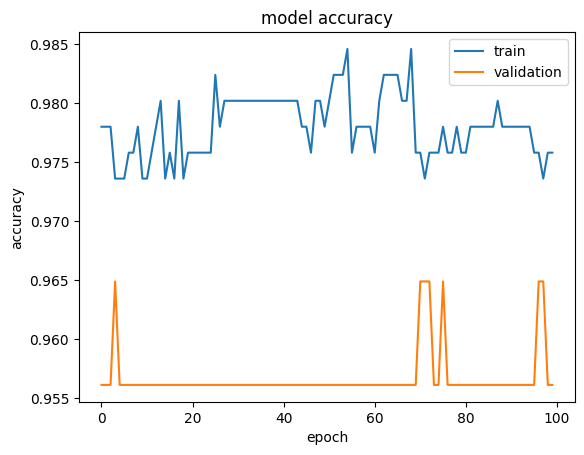

In [139]:
# Plot the accuracy for both train and validation set
plt.subplots() # open a new plot
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'])
plt.show()

### Plot the loss for both train and validation set

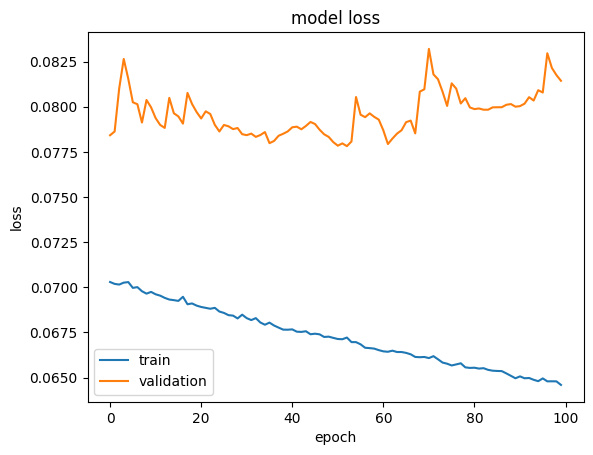

In [142]:
# Plot the loss for both train and validation set
plt.subplots() # open a new plot
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'])
plt.show()

## Implement Callbacks

In [68]:
import tensorflow as tf

In [70]:
class myCallback(tf.keras.callbacks.Callback):
    
    def on_epoch_end(self, epoch, logs={}): # this method will be called everytime at the end of each epoch
        if(logs.get('loss')<0.03):
            print("\nReached 97% accuracy so cancelling training!")
            self.model.stop_training = True
            
callback = myCallback()

In [72]:
history = my_classifier.fit(x_train, y_train, validation_split=0.2,
                            batch_size = 10, epochs = 100, callbacks= [callback])

Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9927 - loss: 0.0481 - val_accuracy: 0.9890 - val_loss: 0.0491
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9911 - loss: 0.0522 - val_accuracy: 0.9890 - val_loss: 0.0495
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9916 - loss: 0.0709 - val_accuracy: 0.9890 - val_loss: 0.0488
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9874 - loss: 0.0678 - val_accuracy: 0.9890 - val_loss: 0.0479
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9953 - loss: 0.0439 - val_accuracy: 0.9890 - val_loss: 0.0478
Epoch 6/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9885 - loss: 0.0689 - val_accuracy: 0.9890 - val_loss: 0.0479
Epoch 7/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9889 - loss: 0.0578 - val_accuracy: 0.9890 - val_loss: 0.0490
Epoch 8/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9706 - loss: 0.0964 - val_accuracy: 0.9890 - v